In [1]:
using Random, Statistics, Plots, ProgressMeter, JSON, StatsBase, Distributions, GLM, LaTeXStrings

In [2]:
# Helper function to sample an integer from a power law distribution.
function sample_powerlaw_int(min_length::Int, max_length::Int, alpha::Float64)
    # Generate a uniform random number between 0 and 1.
    u = rand()
    # Inverse transform sampling for a power law:
    #   F(x) = (x^(1-α) - min_length^(1-α)) / (max_length^(1-α) - min_length^(1-α))
    # Solving for x gives:
    x = ((u * (max_length^(1 - alpha) - min_length^(1 - alpha))) + min_length^(1 - alpha))^(1 / (1 - alpha))
    # Ensure the returned length is at least min_length and at most max_length.
    slice_length = max(min_length, min(max_length, round(Int, x)))
    return slice_length
end

sample_powerlaw_int (generic function with 1 method)

# Structures

## Chromosomes

In [3]:
# Chromosomes Type and Functions
# -------------------------------
mutable struct Chromosomes
    chromosomes_gene_type::Vector{Vector{Int}}
    chromosomes_gene_mut::Vector{Vector{Int}}
    gene_map::Dict{Int,String}
end

function get_Nchrs(ch::Chromosomes)
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        return length(ch.chromosomes_gene_type)
    else
        error("Mismatched chromosome lists.")
    end
end

function get_Ngenes(ch::Chromosomes)
    ngenes = 0
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        for i in 1:length(ch.chromosomes_gene_type)
            if length(ch.chromosomes_gene_type[i]) == length(ch.chromosomes_gene_mut[i])
                ngenes = ngenes+length(ch.chromosomes_gene_type[i])
            else
                error("Mismatched genes lenghts")
            end
        end
        return ngenes
    else
        error("Mismatched chromosome lists.")
    end
end

function mutate!(ch::Chromosomes, mu::Float64)
    n_mut = 0
    for i in 1:get_Nchrs(ch)
        chrom = copy(ch.chromosomes_gene_mut[i])
        # For each gene in the chromosome, mutate with probability mu.
        for j in 1:length(chrom)
            if rand() < mu
                chrom[j] = 1
            end
        end
        ch.chromosomes_gene_mut[i] = chrom
    end
end

function crossover!(ch::Chromosomes, ext_chr_gt::Vector{Int}, ext_chr_gm::Vector{Int})
    idx_chr = rand(1:get_Nchrs(ch))
    ch.chromosomes_gene_type[idx_chr] = vcat(ch.chromosomes_gene_type[idx_chr], ext_chr_gt)
    ch.chromosomes_gene_mut[idx_chr]  = vcat(ch.chromosomes_gene_mut[idx_chr], ext_chr_gm)
end

function get_genes_by_type(ch::Chromosomes, gene_type::String)
    restr_gene_mut_gt = Vector{Vector{Int}}()
    restr_gene_mut_gm = Vector{Vector{Int}}()
    for i in 1:length(ch.chromosomes_gene_type)
        mapped = [ch.gene_map[x] for x in ch.chromosomes_gene_type[i]]
        inds = findall(x -> x == gene_type, mapped)
        push!(restr_gene_mut_gt, ch.chromosomes_gene_type[i][inds])
        push!(restr_gene_mut_gm, ch.chromosomes_gene_mut[i][inds])
    end
    return restr_gene_mut_gt, restr_gene_mut_gm
end


get_genes_by_type (generic function with 1 method)

## Cell

In [4]:
# Cell Type and Methods
# ---------------------
mutable struct Cell
    x::Int
    y::Int
    chromosomes::Chromosomes
    state::Int
    mu0::Float64
    dmu::Float64
    mu::Float64
    r0::Float64
    dr::Float64
    rmax::Float64
    r::Float64
end

get_Nchrs(cell::Cell) = get_Nchrs(cell.chromosomes)

function dead_cell(x::Int, y::Int)
    return Cell(x,y,Chromosomes([],[], Dict()),2,0,0,0,0,0,0,0)
end
"""
    compute_activation(cell, gene_type; mode="any")

Helper function that computes, for a given gene type, an activation Boolean vector
across the unique genes. For mode "any", a gene is activated if at least one chromosome
has it mutated; for mode "all", only if all chromosomes show the mutation.
"""
function compute_activation(cell::Cell, gene_type::String; mode::String="any")
    gene_types, gene_muts = get_genes_by_type(cell.chromosomes, gene_type)
    if all(x -> isempty(x), gene_types)
        return Bool[]
    end
    unique_genes = unique(vcat(gene_types...))
    # For each chromosome, build a Boolean vector indicating for each unique gene if any matching gene is mutated.
    if mode == "any"
        # A gene is activated if any chromosome shows it.
        activation = [ [ any(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ any(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    elseif mode == "all"
        # A gene is activated only if every chromosome shows it.
        activation = [ [ all(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ all(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    else
        error("Invalid mode. Use \"any\" or \"all\".")
    end
end

function update_mu!(cell::Cell)
    act = compute_activation(cell, "I"; mode="any")
    new_mu = cell.mu0 + sum(act) * cell.dmu
    cell.mu = cell.mu0 + sum(act) * cell.dmu
end

function update_r!(cell::Cell)
    act_o = compute_activation(cell, "O"; mode="any")
    act_s = compute_activation(cell, "S"; mode="all")
    new_r = cell.r0 + (sum(act_o) + sum(act_s)) * cell.dr
    cell.r = new_r < cell.rmax ? new_r : cell.rmax
end


function check_cell_death(cell::Cell)
    if get_Nchrs(cell) == 0
        return true
    elseif any(compute_activation(cell, "HK"; mode="all"))
        return true
    else
        return false
    end
end

"""
    update!(cell)

Updates the cell state: first checks for cell death, then applies mutation, and updates
the mutation and reproduction rates. Returns 0 if the cell dies, 1 if it reproduces,
or 2 if nothing happens.
"""
function sample_reproducers(rates::Vector{Float64})
    R = sum(rates)
    K = rand(Poisson(R))

    # if no events, short‐circuit:
    if K == 0
        return falses(length(rates)), zeros(Int, length(rates))
    end

    # pick K events (with replacement) weighted by rates:
    events = sample(1:length(rates), Weights(rates), K; replace=false)

    # tabulate
    counts = zeros(Int, length(rates))
    for i in events
        counts[i] += 1
    end
    reproduced = counts .> 0
    return reproduced, events
end


function copy_cell(cell::Cell)
    new_chromosomes = Chromosomes([copy(arr) for arr in cell.chromosomes.chromosomes_gene_type],
                                  [copy(arr) for arr in cell.chromosomes.chromosomes_gene_mut],
                                  deepcopy(cell.chromosomes.gene_map))
    return Cell(cell.x, cell.y, new_chromosomes, cell.state, cell.mu0, cell.dmu, cell.mu, 
                cell.r0, cell.dr, cell.rmax, cell.r)
end

copy_cell (generic function with 1 method)

## Tissue

In [5]:
# Tissue Type and Functions
# -------------------------
mutable struct Tissue
    L::Int
    cells::Array{Cell,2}
    gene_map::Dict{Int,String}
    neighbor_cache::Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}
end

function compute_neighbors(L::Int, row::Int, col::Int)
    neighbors = Vector{Tuple{Int,Int}}()
    for dr in -1:1
        for dc in -1:1
            if dr == 0 && dc == 0
                continue
            end
            new_row = row + dr
            new_col = col + dc
            if new_row ≥ 1 && new_row ≤ L && new_col ≥ 1 && new_col ≤ L
                push!(neighbors, (new_row, new_col))
            end
        end
    end
    return neighbors
end

function Tissue(L::Int, init_cell_state::Array{Cell,2})
    gene_map = init_cell_state[1,1].chromosomes.gene_map
    neighbor_cache = Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}()
    for i in 1:L, j in 1:L
        neighbor_cache[(i,j)] = compute_neighbors(L, i, j)
    end
    return Tissue(L, init_cell_state, gene_map, neighbor_cache)
end

get_neighbors(tiss::Tissue, row::Int, col::Int) = tiss.neighbor_cache[(row, col)]

function get_actions(tiss::Tissue)
    actions = zeros(Int, tiss.L, tiss.L)
    actions += reshape(sample_reproducers(vec(get_r(tiss)))[1],tiss.L,tiss.L)  # reproducing cells
    return actions
end

function initialize_tiss_indx!(tiss::Tissue)
    for i in 1:tiss.L, j in 1:tiss.L
        tiss.cells[i,j].x = i
        tiss.cells[i,j].y = j
    end
end

function get_idx(tiss::Tissue)
    idx = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        idx[i,j] = (tiss.cells[i,j].x) + (tiss.L*(tiss.cells[i,j].y-1))
    end
    return idx
end

# Helper function for weighted random selection.
function weighted_choice(neighbors::Vector{Tuple{Int,Int}}, weights::Vector{Float64})
    total = sum(weights)
    r = rand() * total
    cum = 0.0
    for (i, w) in enumerate(weights)
        cum += w
        if r < cum
            return neighbors[i]
        end
    end
    return neighbors[end]
end




"""
    substitute!(tiss, action)

For cells that died (action 0), replace them with a copy of a neighbor chosen
with probability proportional to its reproduction rate.
For cells that reproduced (action 1), a neighbor is replaced by a copy of the cell,
or by a split replication with probability p_poly, choosing a neighbot with probability
inversely proportional to the reproduction rate
"""

# small helper to finish off a cell after placement
function _finalize!(cell::Cell, dead_pos::Vector{Tuple{Int,Int}}, i::Int, j::Int)
    mutate!(cell.chromosomes, cell.mu)
    if cell.state == 0
        if sum(sum(cell.chromosomes.chromosomes_gene_mut))!=0
            cell.state=1
        end
    end
    
    if check_cell_death(cell)
        push!(dead_pos, (i,j))
    else
        update_mu!(cell)
        update_r!(cell)
    end
end

function substitute!(tiss::Tissue)
    L = tiss.L
    dead_pos = Vector{Tuple{Int,Int}}()
    # 1) reproducing cells (action == 1)
    repro_positions = findall(reshape(sample_reproducers(vec(get_r(tiss)))[1],tiss.L,tiss.L).==1)
    if length(repro_positions)>1
        for idx in eachindex(repro_positions)
            pos = repro_positions[idx]
            i,j = Tuple(pos)            # unpack the CartesianIndex
            cell = tiss.cells[i,j]
    
            # pick neighbor once
            neighs = get_neighbors(tiss, i, j)
            states = [ tiss.cells[r,c].state for (r,c) in neighs ]
            if !all(states.==0)
                rates = [ tiss.cells[r,c].r for (r,c) in neighs ]
                if any(rates.==0.)
                    ci, cj = neighs[rand(findall(rates.==0.))]
                else
                    inv_rates = 1.0 ./ rates
                    ci, cj = weighted_choice(neighs, inv_rates)
                end
                
                ############################################
                copyc = copy_cell(cell)
                tiss.cells[ci,cj] = copyc
                _finalize!(tiss.cells[i,j], dead_pos, i, j)
                _finalize!(tiss.cells[ci,cj], dead_pos, ci, cj)
                #############################################
            end
        end

        for pos in dead_pos
            i,j = Tuple(pos)
            tiss.cells[i,j] = dead_cell(i,j)
        end
    end
end


function get_r(tiss::Tissue)
    r_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        r_mat[i, j] = tiss.cells[i,j].r
    end
    return r_mat
end

function get_r_canc(tiss::Tissue)
    r_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(r_mat, tiss.cells[i,j].r)
        end
    end
    return mean(r_mat)
end

function get_mu(tiss::Tissue)
    mu_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        mu_mat[i, j] = tiss.cells[i,j].mu
    end
    return mu_mat
end

function get_mu_canc(tiss::Tissue)
    mu_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(mu_mat, tiss.cells[i,j].mu)
        end
    end
    return mean(mu_mat)
end

function get_Nchrs(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Nchrs(tiss.cells[i,j])
    end
    return n_mat
end

function get_avg_genemutation(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = fill(NaN, tiss.L, tiss.L)
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if get_Nchrs(cell) == 0
            mut_state[i,j] = NaN
        else
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, mean(gene_mut_vec[idxs]))
                end
            end
            mut_state[i,j] = mean(means)
        end
    end
    return mut_state
end

function get_avg_genemutation_mean(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = Float64[]
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if cell.state==1
            if get_Nchrs(cell) == 0
                mut_state[i,j] = NaN
            else
                means = Float64[]
                for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                    # Get the gene types and mutation values for chromosome c.
                    gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                    gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                    # Find indices where the gene type is one of the selected keys.
                    idxs = findall(x -> x in selected_keys, gene_types_vec)
                    if !isempty(idxs)
                        push!(means, mean(gene_mut_vec[idxs]))
                    end
                end
                push!(mut_state, mean(means))
            end
        end
    end
    return mean(mut_state), std(mut_state)
end

function get_Ngenes(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Ngenes(tiss.cells[i,j].chromosomes)
    end
    return n_mat
end

diff_flag(a, b) = a == b ? 0 : 1

function get_cancercells(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = tiss.cells[i,j].state
    end
    return sum(n_mat.==1)/tiss.L^2, sum(n_mat.==2)/tiss.L^2
end

function get_state(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = tiss.cells[i,j].state
    end
    return n_mat
end

function copy_tissue(orig::Tissue)
    L = orig.L
    # Deep-copy every cell
    newcells = [ copy_cell(orig.cells[i,j]) for i in 1:L, j in 1:L ]
    # Rebuild a fresh Tissue (this will re-extract gene_map and rebuild neighbor_cache)
    return Tissue(L, newcells)
end

copy_tissue (generic function with 1 method)

# Simulation

## Functions

In [6]:
# Track genomic space transitions
# -------------------------------

# Helper function: converts a cell's genomic state into a canonical string.
# Here we use the mutation arrays for each chromosome.
function get_genomic_state(cell::Cell, gene_map::Dict{Int,String})
    cell = copy_cell(cell)
    chrom_gene_type = cell.chromosomes.chromosomes_gene_type
    chrom_gene_mut = cell.chromosomes.chromosomes_gene_mut
    n_ch = length(gene_map)  # number of distinct gene entries
    counts_ch = Vector[]
    mutation_ch = Vector[]
    
    for i in 1:length(chrom_gene_mut)
        counts = zeros(Int, n_ch)
        mutation_sums = zeros(Int, n_ch)
        for (gt, m) in zip(chrom_gene_type[i], chrom_gene_mut[i])
            mutation_sums[gt] += m
        end
        push!(mutation_ch, mutation_sums)
    end

    # For gene mutations, do the same
    muts_str  = join((join(mutation,"") for mutation in mutation_ch),"/")
    # Combine both parts with a "+"
    return "$muts_str"
end

function get_genomic_state_I(cell::Cell, gene_map::Dict{Int,String}, N_I::Int)
    cell = copy_cell(cell)
    chrom_gene_mut = cell.chromosomes.chromosomes_gene_mut
    n_ch = length(gene_map)  # number of distinct gene entries
    mutation_ch = Vector[]
    
    for i in 1:length(chrom_gene_mut)
        mutation_sums = zeros(Int, n_ch)
        for m in chrom_gene_mut[i]
            mutation_sums[gt] += chrom_gene_mut[i][1:N_I]
        end
        push!(mutation_ch, mutation_sums)
    end

    # For gene mutations, do the same
    muts_str  = join((join(mutation,"") for mutation in mutation_ch),"/")
    # Combine both parts with a "+"
    return "$muts_str"
end

death_state = "66666+11111"

# Function to record a transition from prev_state to new_state.
function track_transition!(prev_state::Int, new_state::Int)
    key = (prev_state, new_state)
    # Increment the count if the key exists, otherwise initialize it to 1.
    STATE_SPACE[key] = get(STATE_SPACE, key, 0) + 1
end

function save_genomicstate(state_space::Dict{Tuple{String, String}, Int}, fname::String, dname::String)
    # 1. Collect all unique states from the keys.
    all_states = unique(vcat([k[1] for k in keys(state_space)],
                             [k[2] for k in keys(state_space)]))
    
    # 2. Create a dictionary mapping each state string to a unique number.
    state_dict = Dict(state => i for (i, state) in enumerate(all_states))
    
    # 3. Create a vector of triples: (state_out_number, state_in_number, transition count).
    transitions = [(state_dict[k[1]], state_dict[k[2]], count) for (k, count) in state_space]
    
    # For example, print the state mapping and the transitions vector:
    
    
    open(fname, "w") do io
        for (state_out, state_in, count) in transitions
            println(io, "$state_out $state_in $count")
        end
    end

    json_str = JSON.json(state_dict)
    open(dname, "w") do io
        write(io, json_str)
    end
    return state_dict
end

save_genomicstate (generic function with 1 method)

In [7]:
# Create Gene Map 
# ---------------

function create_gene_map(n_I::Int, n_O::Int, n_S::Int, n_HK::Int)
    types = vcat(fill("I", n_I), fill("O", n_O), fill("S", n_S), fill("HK", n_HK))
    return Dict(i => types[i] for i in 1:length(types))
end

create_gene_map (generic function with 1 method)

In [8]:
# Simulation loop
function simulation(tiss::Tissue, n_steps::Int, n_it_store::Int, track_state::Bool, bar=true, limit=0.5)
    ##
    mus = Float64[]
    rs = Float64[]
    tumors = Float64[]
    dcells = Float64[]
    tissues = Tissue[]
    muts_I = Float64[]
    muts_I_std = Float64[]
    muts_O = Float64[]
    muts_S = Float64[]
    muts_HK = Float64[]
    count_list = Vector{Vector{Float64}}()
    
    final_state = "Done"
    
    @showprogress enabled=bar for k in 1:n_steps
        substitute!(tiss)  # Update system stat
        # Save important quantities
        mu = get_mu_canc(tiss) # mutation rate
        push!(mus, mu)
        r = get_r_canc(tiss) #growth rate
        push!(rs, r)
        tumorsize, death_cells = get_cancercells(tiss) #number of cell not wild type
        push!(tumors, mean(tumorsize))
        push!(dcells, mean(death_cells))
        
        push!(muts_I, get_avg_genemutation_mean(tiss, ["I"])[1])
        push!(muts_I_std, get_avg_genemutation_mean(tiss, ["I"])[2])
        push!(muts_O, get_avg_genemutation_mean(tiss, ["O"])[1])
        push!(muts_S, get_avg_genemutation_mean(tiss, ["S"])[1])
        push!(muts_HK, get_avg_genemutation_mean(tiss, ["HK"])[1])

        sizz = length(findall(x-> x==1, get_state(tiss)))
        i_state = get_mu(tiss)[findall(x-> x==1, get_state(tiss))]
        cm = sort(collect(countmap(i_state)); by=first)
        countss = [(cm[i][2]/sizz) for i in 1:length(cm)] 
        push!(count_list, countss)
        
        # store a tissue object every x iterations
        if rem(k,n_it_store)==0
            push!(tissues, copy_tissue(tiss)) 
            
        end
    
        # Conditions to end the simulation

        # 1. all the cells are wt (tumor exthinguished)
        if all(tumorsize.==0)
            println("All normal cells at iteration ", k)
            final_state = "Health"
            break
        end
        # 2. if the tumors size if larger than 50%
        if mean(tumorsize)>limit
            println("Tumor size limit reached at iteration ", k)
            final_state="Tumor"
            break
        end
    end
    return (final_state, tissues, mus, rs, tumors, dcells, muts_I, muts_I_std, muts_O, muts_S, muts_HK, count_list)
end

simulation (generic function with 3 methods)

In [9]:
# Create the individual heatmap plots:

function plot_quant(tiss)
    p1 = heatmap(get_r(tiss),
                 color = :blues,
                 clims = (r0, 2*r0),
                 title = "Growth rate",
                 xticks = false,
                 yticks = false)
    
    p2 = heatmap(get_mu(tiss),
                 color = :reds,
                 clims = (mu0, mu0+N_I*dmu), # adjust as needed
                 title = "Mutation rate",
                 xticks = false,
                 yticks = false)
    
    #p3 = heatmap(get_Nchrs(tiss),
    #             color = :greens,
    #             #clims = (r0, rmax),
    #             title = "Number of chromosomes",
    #             xticks = false,
    #             yticks = false)
    
    #p4 = heatmap(get_Ngenes(tiss),
    #             color = :grays,
    #             #clims = (0, 5), # adjust as needed
    #             title = "Number of genes",
    #             xticks = false,
    #             yticks = false)
    
    p_res = plot(p1, p2, layout = (1, 2), size = (1000, 400))
    display(p_res)
end

function plot_gen(tiss)
    gtype_p5 = ["I"]
    p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p6 = ["O"]
    p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p7 = ["S"]
    p7 = heatmap(get_avg_genemutation(tiss, gtype_p7),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p7, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p8 = ["HK"]
    p8 = heatmap(get_avg_genemutation(tiss, gtype_p8),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p8, "-") * " genes",
                 xticks = false,
                 yticks = false)
    
    p_gen = plot(p5, p6, p7, p8, layout = (2, 2), size = (1000, 800))
end

plot_gen (generic function with 1 method)

In [10]:
# plot quantities
function plot_quantities(mu_canc, r_canc)
    
    plt_1 = plot(title="Mutation rate", legend=false)
    plot!(mu_canc)#, xlims=[0,xlim])#, ylims=[mu0+dmu-0.0005,0.0105])

    plt_2 = plot(title="Growth rate", legend=false)
    plot!(r_canc)#, ylims=[r0+dr, rmax])
    
    p_progr = plot(plt_1, plt_2, layout = (1, 2), size = (1000, 400))
    #p_progr = plot(plt_1, plt_2, plt_5, layout = (1, 3), size = (1200, 300))
    
    
    display(p_progr)
end

plot_quantities (generic function with 1 method)

In [11]:
# Tissue Initialization
# --------------------
function init_tissue(L::Int, chrom_gene_type::Vector{Vector{Int}}, chrom_gene_mut::Vector{Vector{Int}}, 
    gene_map::Dict{Int,String}, 
    mu0::Float64, dmu::Float64, 
    r0::Float64, dr::Float64, rmax::Float64)
    cells = Array{Cell}(undef, L, L)
    for i in 1:L, j in 1:L
        ch = Chromosomes(copy(chrom_gene_type), copy(chrom_gene_mut), gene_map)
        cells[i,j] = Cell(i, j, ch, 0, mu0, dmu, mu0,
                                    r0, dr, rmax, r0)
    end
    return Tissue(L, cells)
end

# Perturbation of the initial state
# ---------------------------------
function perturb_init_tissue!(tiss::Tissue, r::Float64, pert_chrom_gene_type::Vector{Vector{Int}}, pert_chrom_gene_mut::Vector{Vector{Int}})
    for i in 1:L
        for j in 1:L
            if (i-L//2)^2+(j-L//2)^2 <= (r*L)^2
                tiss.cells[i,j].chromosomes.chromosomes_gene_mut = copy(pert_chrom_gene_mut)
                tiss.cells[i,j].chromosomes.chromosomes_gene_type = copy(pert_chrom_gene_type)
                tiss.cells[i,j].state=1
                update_mu!(tiss.cells[i,j])
                update_r!(tiss.cells[i,j])
            end
        end
    end
end


perturb_init_tissue! (generic function with 1 method)

In [12]:
function save_to_file(file::Any, name::String, vec_of_vec::Bool)
    open(string(name), "w") do io
        if vec_of_vec      
            for mi in file
                println(io, join(mi, ", "))  # comma-separated values
            end
        else
            for mi in file
                println(io, mi)  # comma-separated values
            end
        end
    end
end

save_to_file (generic function with 1 method)

## Runn

In [46]:
1-(1-0.02)^5

0.09607920320000007

In [58]:
#### Single run simulation ####
###############################

#### Chromosome parameters #####
N_I  = 10
N_O  = 15
N_S  = 5
N_HK = 10
N0_genes  = N_I+N_O+N_S+N_HK
gene_map = create_gene_map(N_I, N_O, N_S, N_HK)

#### Wild Type Chromosome ####
chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]

#### Perturbed Chromosome ####
pert_chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes), collect(1:N0_genes)]
#pert_chrom_gene_mut = [fill(1,N0_genes), fill(0,N0_genes)]
#[pert_chrom_gene_mut[1][i] = 0 for i in 2:10]
#[pert_chrom_gene_mut[2][i] = 1 for i in 21:30]
pert_chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes), fill(0,N0_genes)]
pert_chrom_gene_mut[1][1] = 1
[pert_chrom_gene_mut[1][i+N_I] = 1 for i in 1:2]
[pert_chrom_gene_mut[1][i+N_I+N_O+N_S] = 1 for i in 1:N_HK]
[pert_chrom_gene_mut[2][i+N_I+N_O+N_S] = 1 for i in 1:N_HK]
#[pert_chrom_gene_mut[2][i+N_I+N_O] = 1 for i in 1:10]

#### Tissue parameters ####
L       = 100
mu0     = 0.
dmu     = 5e-3
r0      = 2e-1
dr      = 2e-2

#### Simulation ####
tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, r0, dr, 2*r0)
perturb_init_tissue!(tiss, 0.1, pert_chrom_gene_type, pert_chrom_gene_mut)

state, tissues, mus, rs, tumors, dcells, muts_I, muts_I_std, muts_O, muts_S, muts_HK, count_list = simulation(tiss,1000,1000, false, true, 0.5)

#### Save to file ####
save_to_file(mus, "../Data/CancerEvo/single/m_4chr.txt", false)
save_to_file(rs, "../Data/CancerEvo/single/r_4chr.txt", false)
save_to_file(muts_HK, "../Data/CancerEvo/single/k_4chr.txt", false)
save_to_file(tumors, "../Data/CancerEvo/single/t_4chr.txt", false)
save_to_file(muts_I_std, "../Data/CancerEvo/single/mstd_4chr.txt", false)
save_to_file(count_list, "../Data/CancerEvo/single/counts_4chr.txt", true)

println("Done")

Progress:  62%|█████████████████████████▋               |  ETA: 0:01:03

Tumor size limit reached at iteration 625

Progress: 100%|█████████████████████████████████████████| Time: 0:01:44



Done


In [16]:
#### Track Transitions ####
###########################

flux_vec = Vector{Vector{Float64}}()
count_vec = Vector{Vector{Float64}}()
STATE_SPACE = Dict{Tuple{Int, Int}, Int}()
@showprogress for i in 1:20
    STATE_SPACE = Dict{Tuple{Int, Int}, Int}()
    death_state=666
    # Update system and track transition in genomic space
    old_state = Matrix{Int}(undef, L, L)
    for i in 1:L, j in 1:L
        if tiss.cells[i,j]==2
            old_state[i,j] = 666
        else
            old_state[i,j] = sum(compute_activation(tiss.cells[i,j],"I"))
        end
    end
    
    initialize_tiss_indx!(tiss)
    old_idx = get_idx(tiss)
    substitute!(tiss)  # Update system state
    new_idx = get_idx(tiss)
    
    i_state = get_mu(tiss)[findall(x-> x==1, get_state(tiss))]
    cm = sort(collect(countmap(i_state)); by=first)
    countss = [(cm[i][2]) for i in 1:length(cm)] 
    push!(count_vec, countss)
    
    for pos in findall(x->x!=0, get_state(tiss))
        i,j = Tuple(pos)
        search = tiss.cells[new_idx.==old_idx[i,j]]
        if isempty(search)
            track_transition!(old_state[i,j], 444)
        else
            for t in search
                if t.state==2
                     track_transition!(old_state[i,j], 666)
                else
                    track_transition!(old_state[i,j], sum(compute_activation(t,"I")))
                end
            end
        end
    end
    
    I_act_state = Matrix{Int}(undef, L,L)
    for i in 1:L, j in 1:L
        I_act_state[i,j] = sum(compute_activation(tiss.cells[i,j],"I"))
    end

    # Interesting transitions
    touple_list = [(1,2),(1,3),(2,3),(2,4),(3,4),(3,5),(4,5),(1,444),(2,444),(3,444),(4,444),(5,444),(1,666),(2,666),(3,666),(4,666),(5,666)]
    
    flux = Float64[]
    for t in touple_list
        push!(flux, STATE_SPACE[t]/length(findall(x->x==t[1], I_act_state))*100)
    end
    push!(flux_vec, flux)
end

#save_to_file(flux_vec, "../Data/CancerEvo/transitions/flux_1.txt", true)
#save_to_file(count_vec, "../Data/CancerEvo/transitions/counts_1.txt", true)

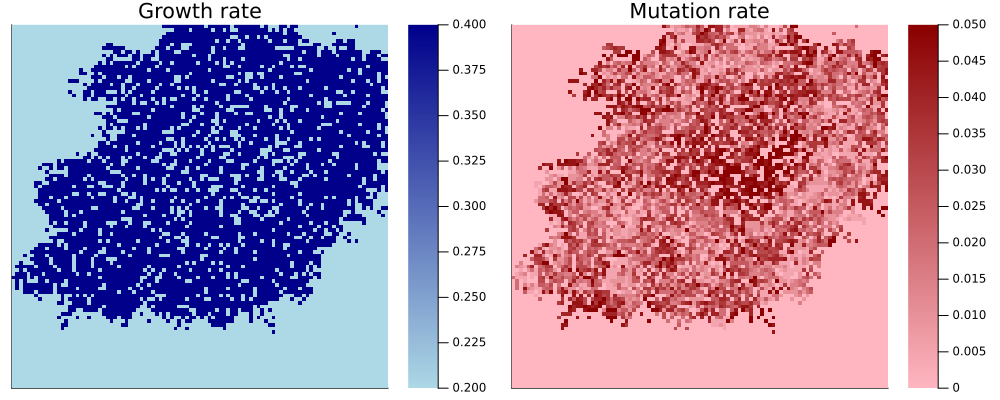

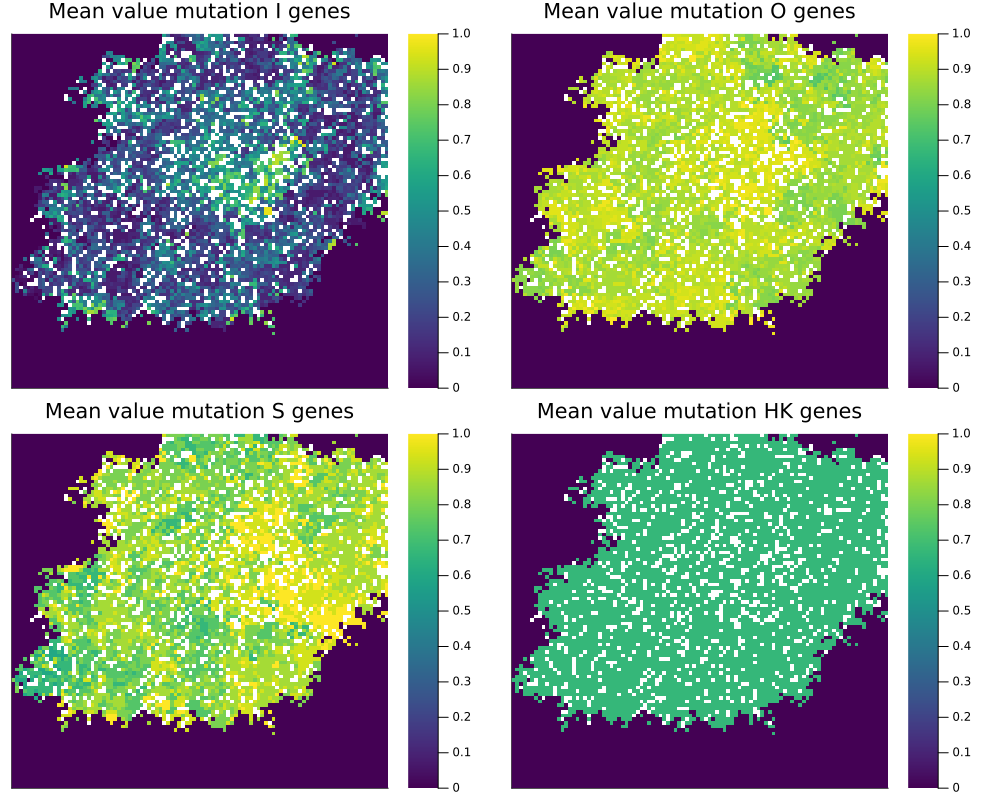

In [59]:
##### HEATMAPS ######
#####################

idx = 10
plot_quant(tiss)
plot_gen(tiss)

In [46]:
# saveimages for gif
c=0
mkdir("../Data/CancerEvo/gif")
for tiss in tissues
    gtype_p5 = ["I"]
    p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p6 = ["O"]
    p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p7 = ["S"]
    p7 = heatmap(get_avg_genemutation(tiss, gtype_p7),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p7, "-") * " genes",
                 xticks = false)
    gtype_p8 = ["HK"]
    p8 = heatmap(get_avg_genemutation(tiss, gtype_p8),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p8, "-") * " genes",
                 xticks = false)
    
    plot(p5, p6, p7, p8, layout = (2, 2), size = (1000, 800))
    savefig(string("../Data/CancerEvo/gif/image",c,".png"))
    c =c+1
end

# Multiple repetitions

In [ ]:
# Multiple repetitions
# --------------
states = Vector{String}()
mu_total = Vector{Vector{Float64}}()
r_total = Vector{Vector{Float64}}()
tumor_total = Vector{Vector{Float64}}()
mut_I_total = Vector{Vector{Float64}}()
mut_O_total = Vector{Vector{Float64}}()
mut_S_total = Vector{Vector{Float64}}()
mut_HK_total = Vector{Vector{Float64}}()


# Model parameters
# ----------------
gene_map = create_gene_map(10, 10, 10, 15)
N0_genes = length(gene_map)
wt_state = repeat("1",N0_genes)*"/"*repeat("1",N0_genes)*"+"*repeat("0",N0_genes)*"/"*repeat("0",N0_genes)

chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
chrom_gene_mut  = [zeros(Int, N0_genes), zeros(Int, N0_genes)]

L       = 100
mu0     = 0.
dmu     = 8e-3
r0      = 2e-1
dr      = 2e-2
rmax    = 2 * r0

for nr in 1:200
    println("Iteration ", nr)
    # Initialization
    # --------------
    chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
    pert_chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]#, collect(1:N0_genes), collect(1:N0_genes)]
    
    chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]
    
    pert_chrom_gene_mut = [[1,0,0,0,0,0,0,0,0,0,
                            1,0,0,0,0,0,0,0,0,0,
                            0,0,0,0,0,0,0,0,0,0,
                            0,0,0,0,0,0,0,0,0,0,0,0,0,0,0], 
                           fill(0,N0_genes)]#, fill(0,N0_genes), fill(0,N0_genes)]

    tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, r0, dr, rmax)
    
    for i in 1:L
        for j in 1:L
            if (i-L//2)^2+(j-L//2)^2 <= 3^2
                tiss.cells[i,j].chromosomes.chromosomes_gene_mut = copy(pert_chrom_gene_mut)
                tiss.cells[i,j].chromosomes.chromosomes_gene_type = copy(pert_chrom_gene_type)
                tiss.cells[i,j].state=1
                update_mu!(tiss.cells[i,j])
                update_r!(tiss.cells[i,j])
            end
        end
    end
    
    state, tissues, mus, rs, ngs, ncs, tumors, dcells, muts_I, muts_O, muts_S, muts_HK = simulation(tiss, 5000,10000, false)

    
    # Storing quantities
    # ------------------
    #push!(states, state)
    push!(mu_total, mus)
    push!(r_total, rs)
    push!(tumor_total, tumors)
    push!(mut_I_total, muts_I)
    push!(mut_O_total, muts_O)
    push!(mut_S_total, muts_S)
    push!(mut_HK_total, muts_HK)
    
end

In [ ]:
# Save to file
# ------------
idx=17

open(string("../Data/CancerEvo/",idx,"_mu.txt"), "w") do io
    for row in mu_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_r.txt"), "w") do io
    for row in r_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

#open(string("../Data/CancerEvo/",idx,"_state.txt"), "w") do io
#    for row in states
#        println(io, row)  # comma-separated values
#    end
#end

#open(string("../Data/CancerEvo/",idx,"_nc.txt"), "w") do io
#    for row in nc_total
#        println(io, join(row, ", "))  # comma-separated values
#    end
#end
#
#open(string("../Data/CancerEvo/",idx,"_ng.txt"), "w") do io
#    for row in ng_total
#        println(io, join(row, ", "))  # comma-separated values
#    end
#end

open(string("../Data/CancerEvo/",idx,"_c.txt"), "w") do io
    for row in tumor_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_O.txt"), "w") do io
    for row in mut_O_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_I.txt"), "w") do io
    for row in mut_I_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_S.txt"), "w") do io
    for row in mut_S_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_HK.txt"), "w") do io
    for row in mut_HK_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

In [14]:
println("Probability health: ", sum(states.=="Health")/length(states))
println("Probability tumor: ", sum(states.=="Tumor")/length(states))
println("Probability done: ", sum(states.=="Done")/length(states))

Probability health: 0.6956521739130435
Probability tumor: 0.30434782608695654
Probability done: 0.0


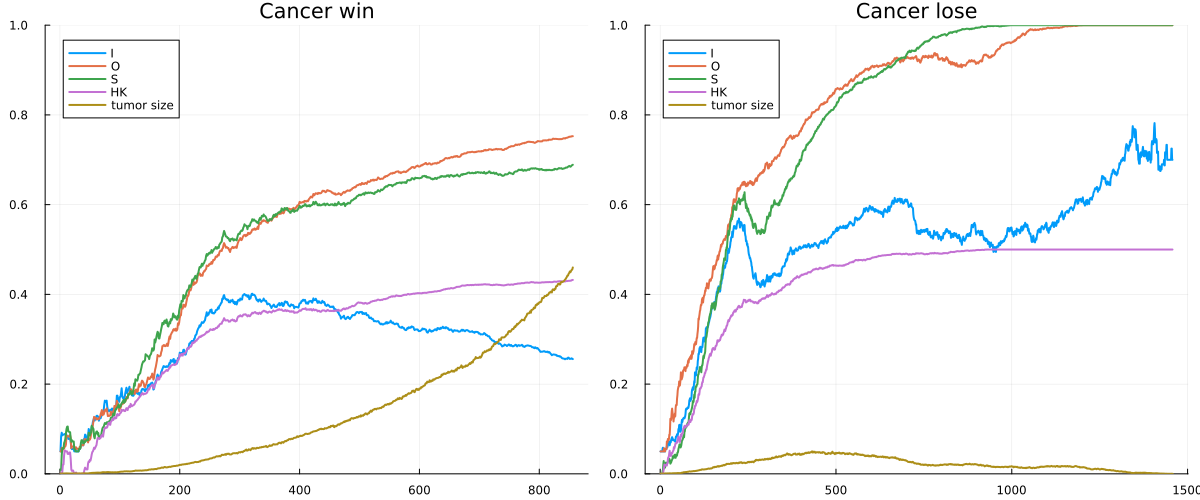

In [20]:
# Plot mutation trajectories #
p1 = plot(title="Cancer win", ylims=[0,1])
idx_t=findall(states.=="Tumor")[3]
plot!(mut_I_total[idx_t], label="I", lw=2)
plot!(mut_O_total[idx_t], label="O", lw=2)
plot!(mut_S_total[idx_t], label="S", lw=2)
plot!(mut_HK_total[idx_t], label="HK", lw=2)
plot!(tumor_total[idx_t], label="tumor size", lw=2)

p2 = plot(title="Cancer lose", ylims=[0,1])
idx_h=findall(states.=="Health")[1]
plot!(mut_I_total[idx_h], label="I", lw=2)
plot!(mut_O_total[idx_h], label="O", lw=2)
plot!(mut_S_total[idx_h], label="S", lw=2)
plot!(mut_HK_total[idx_h], label="HK", lw=2)
plot!(tumor_total[idx_h], label="tumor size", lw=2)

plot(p1,p2,layout=(1,2),size=(1200,500))

In [ ]:
##### BUILD PHASE DIAGRAM #####
###############################

N_I  = 10
N_O  = 10
N_S  = 10
N_HK = 10
N0_genes  = N_I+N_O+N_S+N_HK
gene_map = create_gene_map(N_I, N_O, N_S, N_HK)

chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
pert_chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]

chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]

pert_chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]
pert_chrom_gene_mut[1][1] = 1
pert_chrom_gene_mut[1][1+N_I] = 1


r_prop_list = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
objs = [0.5,0.7,1.0,1.8,2.3,2.7,3.1,3.4,3.6,3.77,3.9]
mu_list = [LinRange(o-0.4,o+0.4,6) for o in objs]

L       = 200
mu0     = 0.
dmu     = 8e-3
r0      = 2e-1
dr      = 2e-2
steps = 500

results = Float64[]
for i in 1:length(r_prop_list)
    rrr = r_prop_list[i]
    print(rrr)
    coeffs = Float64[]
    stderrs = Float64[]
    for mmm in mu_list[i]
        tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, mmm*1e-3, r0, dr, rrr*r0)
        
        perturb_init_tissue!(tiss, 0.3, pert_chrom_gene_type, pert_chrom_gene_mut)
        
        state, tissues, mus, rs, tumors, dcells, muts_I, muts_I_std, muts_O, muts_S, muts_HK = simulation(tiss, steps,10000, false)
        
        X=(1:length(tumors))./steps; Y=tumors; data = (;X, Y)
        res = lm(@formula(Y~X), data)
        push!(coeffs, coef(res)[2])
        push!(stderrs, stderror(res)[2])
    end
    X=mu_list[i]; Y=coeffs; data = (;X, Y)
    res = lm(@formula(Y~X), data)
    push!(results, -coef(res)[1]/coef(res)[2])
end
println("Done")